# Neighbourhood-Level Property Value Visualization

## Purpose

This notebook visualizes descriptive property-value change metrics by `neighbourhood_code`, using the processed output from Notebook 08 (`08_neighbourhood_property_value_analysis.ipynb`). The goal is to produce a portfolio-ready horizontal bar chart showing the median assessed property value change across coded geography groups.

## Caveat

`neighbourhood_code` is a coded geography field. A mapping table or official documentation may be needed later to translate codes into readable neighbourhood labels.

## Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Paths

Define input and output paths. The input is the neighbourhood-level processed CSV from Notebook 08. The output is a PNG chart saved to the `visuals/` directory.

In [10]:
INPUT_PATH = Path("../data/processed/property_value_change_by_neighbourhood.csv")
VISUALS_DIR = Path("../visuals")
OUTPUT_PATH = VISUALS_DIR / "median_property_value_change_by_neighbourhood_code.png"

## Load and Validate

Read the CSV and run basic validation checks: shape, column names, total property count, duplicate `neighbourhood_code` entries, and missing `neighbourhood_code` values.

In [11]:
df = pd.read_csv(INPUT_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Total property_count:", df["property_count"].sum())
print("Duplicate neighbourhood_code count:", df["neighbourhood_code"].duplicated().sum())
print("Missing neighbourhood_code count:", df["neighbourhood_code"].isna().sum())

Shape: (30, 18)
Columns: ['neighbourhood_code', 'property_count', 'valid_percentage_change_count', 'median_current_total_assessed_value', 'median_previous_total_assessed_value', 'median_absolute_value_change', 'median_percentage_value_change', 'mean_percentage_value_change', 'increase_count', 'decrease_count', 'no_change_count', 'missing_percentage_change_count', 'share_increase', 'share_decrease', 'share_no_change', 'share_missing_percentage_change', 'extreme_high_count', 'extreme_low_count']
Total property_count: 1552663.0
Duplicate neighbourhood_code count: 0
Missing neighbourhood_code count: 0


## Visualization

Create a horizontal bar chart showing `median_percentage_value_change` for each `neighbourhood_code`, sorted ascending. Assessed values are administrative property-tax valuations, not MLS sale prices — this distinction is noted in the chart subtitle.

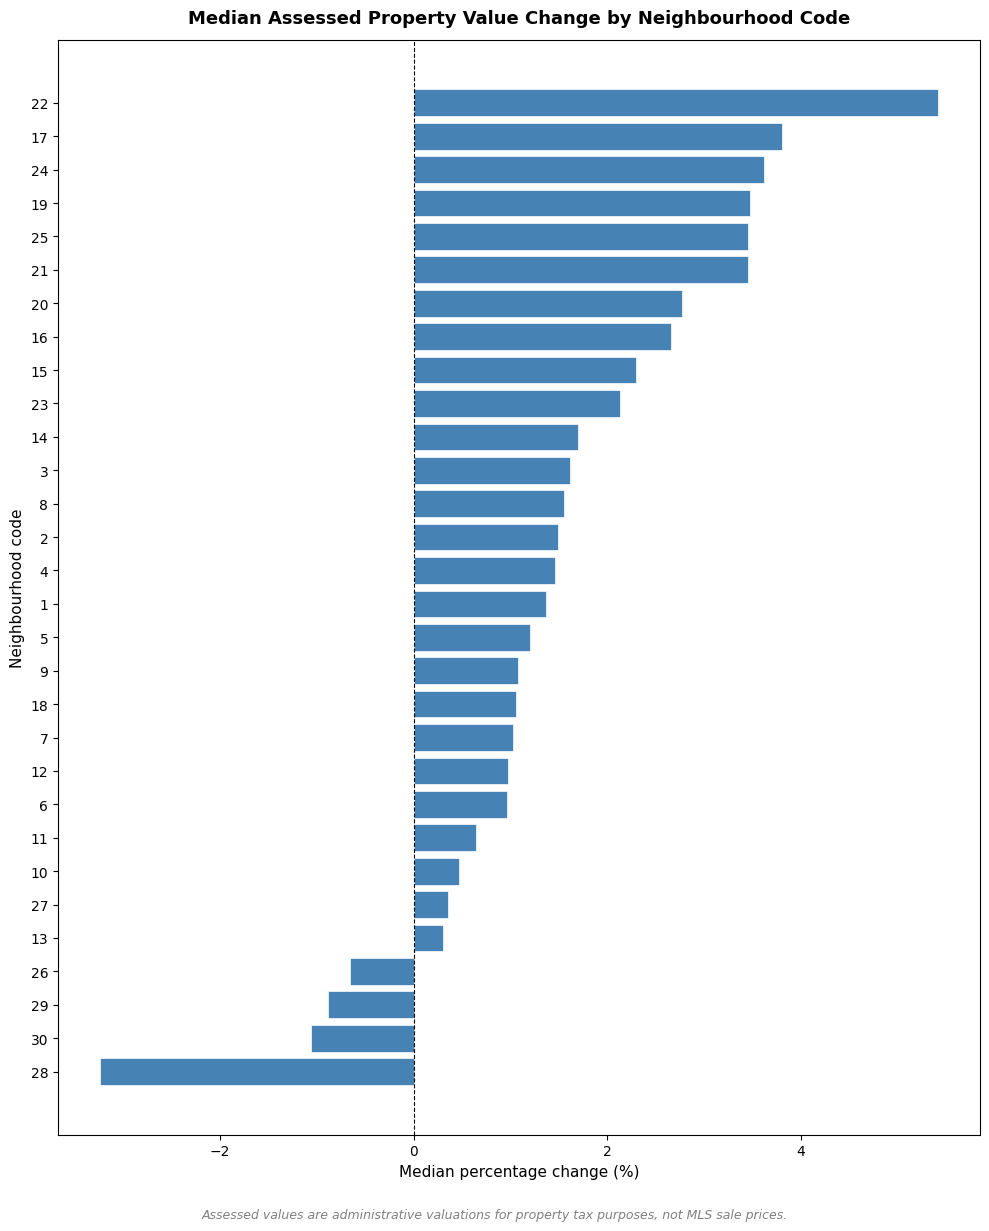

In [12]:
CHART_TITLE = "Median Assessed Property Value Change by Neighbourhood Code"
CHART_NOTE = "Assessed values are administrative valuations for property tax purposes, not MLS sale prices."
X_LABEL = "Median percentage change (%)"
Y_LABEL = "Neighbourhood code"

df_sorted = df.sort_values("median_percentage_value_change", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_sorted) * 0.4)))

ax.barh(
    df_sorted["neighbourhood_code"].astype(str),
    df_sorted["median_percentage_value_change"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,)

ax.set_title(CHART_TITLE, fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel(X_LABEL, fontsize=11)
ax.set_ylabel(Y_LABEL, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

fig.text(
    0.5, -0.02,
    CHART_NOTE,
    ha="center",
    fontsize=9,
    color="gray",
    style="italic",)

plt.tight_layout()
plt.show()

## Export

Save the chart to `visuals/` at 300 dpi for print and portfolio use. The `visuals/` directory is created if it does not already exist.

In [13]:
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

df_sorted = df.sort_values("median_percentage_value_change", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_sorted) * 0.4)))

ax.barh(
    df_sorted["neighbourhood_code"].astype(str),
    df_sorted["median_percentage_value_change"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,)

ax.set_title(CHART_TITLE, fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel(X_LABEL, fontsize=11)
ax.set_ylabel(Y_LABEL, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

fig.text(
    0.5, -0.02,
    CHART_NOTE,
    ha="center",
    fontsize=9,
    color="gray",
    style="italic",)

plt.tight_layout()
fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.close(fig)

## Final Validation

Confirm the output file was written successfully by printing the path, existence check, and file size.

In [14]:
print(f"Output path: visuals/{OUTPUT_PATH.name}")
print("File exists:", OUTPUT_PATH.exists())
if OUTPUT_PATH.exists():
    size_kb = OUTPUT_PATH.stat().st_size / 1024
    print(f"File size: {size_kb:.1f} KB")

Output path: visuals/median_property_value_change_by_neighbourhood_code.png
File exists: True
File size: 182.5 KB
